### Step 1 : Problem Statement
- Predict the insurance charges based on available features

In [1]:
# check python version
!python -V

Python 3.11.0


In [2]:
# load and install the basic libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load libraries to supress warnigs
import warnings
warnings.filterwarnings(action='ignore')

### Step 2 : Data Gathering
- Read and Load dataset

In [3]:
df = pd.read_csv('csv/medical_insurance.csv')
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Step 3 : EDA

In [4]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
# encode values of object dtype

In [7]:
df['gender'].value_counts().to_dict()

{'male': 676, 'female': 662}

In [8]:
df['gender'].replace({'male': 1, 'female': 0}, inplace = True)

In [9]:
df['smoker'].value_counts().to_dict()

{'no': 1064, 'yes': 274}

In [10]:
df['smoker'].replace({'no': 0, 'yes': 1}, inplace = True)

In [11]:
df.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [12]:
df = pd.get_dummies(df, columns=['region'], dtype = int)
df

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


### Step 4 : Feature selection

In [13]:
# check corr()
df.corr()

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008,0.002475,-0.000407,-0.011642,0.010016
gender,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292,-0.002425,-0.011156,0.017117,-0.004184
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341,-0.138156,-0.135996,0.270025,-0.006205
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998,-0.022808,0.024806,-0.023066,0.021914
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251,0.002811,-0.036945,0.068498,-0.036945
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000,0.006349,-0.039905,0.073982,-0.043210
region_northeast,0.002475,-0.002425,-0.138156,-0.022808,0.002811,0.006349,1.000000,-0.320177,-0.345561,-0.320177
region_northwest,-0.000407,-0.011156,-0.135996,0.024806,-0.036945,-0.039905,-0.320177,1.000000,-0.346265,-0.320829
region_southeast,-0.011642,0.017117,0.270025,-0.023066,0.068498,0.073982,-0.345561,-0.346265,1.000000,-0.346265
region_southwest,0.010016,-0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320177,-0.320829,-0.346265,1.000000


<Axes: >

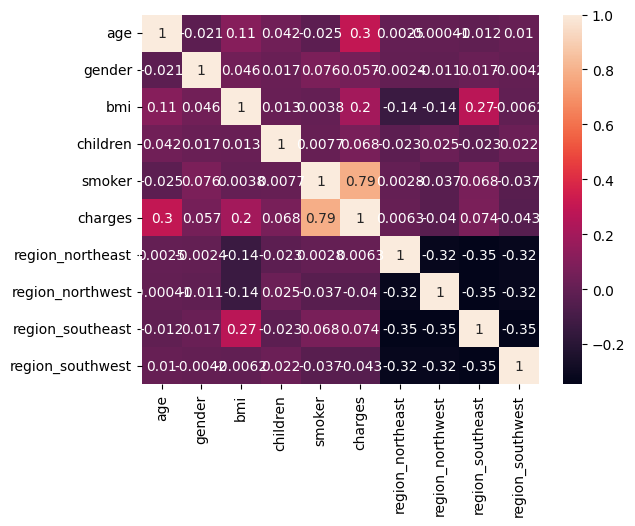

In [14]:
sns.heatmap(data=df.corr(), annot=True)

In [15]:
# cal VIF (variable inflation factor)

from statsmodels.stats.outliers_influence import variance_inflation_factor
x = df.drop('charges', axis = 1)

vif_value = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_value

[np.float64(1.0168221490038107),
 np.float64(1.008900162100573),
 np.float64(1.1066297324286174),
 np.float64(1.0040106421370243),
 np.float64(1.0120736649061481),
 np.float64(8.603068768898916),
 np.float64(8.636204844042899),
 np.float64(11.535194994662813),
 np.float64(9.218448877575907)]

In [16]:
s1 = pd.Series(vif_value, index = x.columns)
s1

age                  1.016822
gender               1.008900
bmi                  1.106630
children             1.004011
smoker               1.012074
region_northeast     8.603069
region_northwest     8.636205
region_southeast    11.535195
region_southwest     9.218449
dtype: float64

### Step 5 : Feature Selection

In [17]:
# use filter, wrapper and Embedded method

### Step 6 : Model Training

In [18]:
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

In [19]:
# split independent and dependent data
X = df.drop('charges', axis = 1)
y = df['charges']

In [20]:
# split train test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1003, 9), (335, 9), (1003,), (335,))

In [21]:
# model traning
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [22]:
# for training data
lr_model.score(X_train, y_train)

0.7449555328228536

In [23]:
# for testing data
lr_model.score(X_test, y_test)

0.7672642952734358

### step 7 : Model Evalution

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
# for training data
y_pred_train = lr_model.predict(X_train)
def model_eval(y_train, y_pred_train):
    mse = mean_squared_error(y_train, y_pred_train)
    print('MSE :' , mse)
    mae = mean_absolute_error(y_train, y_pred_train)
    print('MAE :', mae)
    rmse = np.sqrt(mse)
    print('RMSE : ', rmse)
    r2 = r2_score(y_train, y_pred_train)
    print('R2_score :', r2)
    n,k = X_train.shape
    adj_r2 = 1 - (((1-r2)*(n-1))/(n-k-1))
    print("Adjusted R2 Value: ", adj_r2)

model_eval(y_train, y_pred_train)

MSE : 37004502.18409475
MAE : 4183.153367011967
RMSE :  6083.132596294014
R2_score : 0.7449555328228536
Adjusted R2 Value:  0.7426439515493448


In [26]:
# for testing data
y_pred_test = lr_model.predict(X_test)
def model_eval(y_test, y_pred_test):
    mse = mean_squared_error(y_test, y_pred_test)
    print('MSE :' , mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    print('MAE :', mae)
    rmse = np.sqrt(mse)
    print('RMSE : ', rmse)
    r2 = r2_score(y_test, y_pred_test)
    print('R2_score :', r2)
    n,k = X_train.shape
    adj_r2 = 1 - (((1-r2)*(n-1))/(n-k-1))
    print("Adjusted R2 Value: ", adj_r2)

model_eval(y_test, y_pred_test)

MSE : 35117755.73613631
MAE : 4243.654116653135
RMSE :  5926.023602394468
R2_score : 0.7672642952734358
Adjusted R2 Value:  0.7651549082215333


In [27]:
# creating pickle and json files

In [28]:
import pickle
import json

In [29]:
#  for flask we need this file
with open('lr_model.pkl','wb') as fp:
    pickle.dump(lr_model, fp)

In [30]:
#  for flask we need this file
label_enc_data = {"smoker" : {'no': 0, 'yes': 1},
                "gender" : {'male':1, 'female':0}}

with open('label_enc_data.json', 'w') as f:
    json.dump(label_enc_data,f)

In [31]:
#  to map columns in flask
columns_list = list(X.columns)

In [32]:
d1 = {'columns': columns_list}
# d1
import json
with open('feature.json','w') as file:
    json.dump(d1,file)

### Step 8 : API Creation

### Step 9 : Model Deployments